In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
df = pd.read_csv("Iris.csv")

print(df.head())
print(df.info())
print(df.describe())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None
               

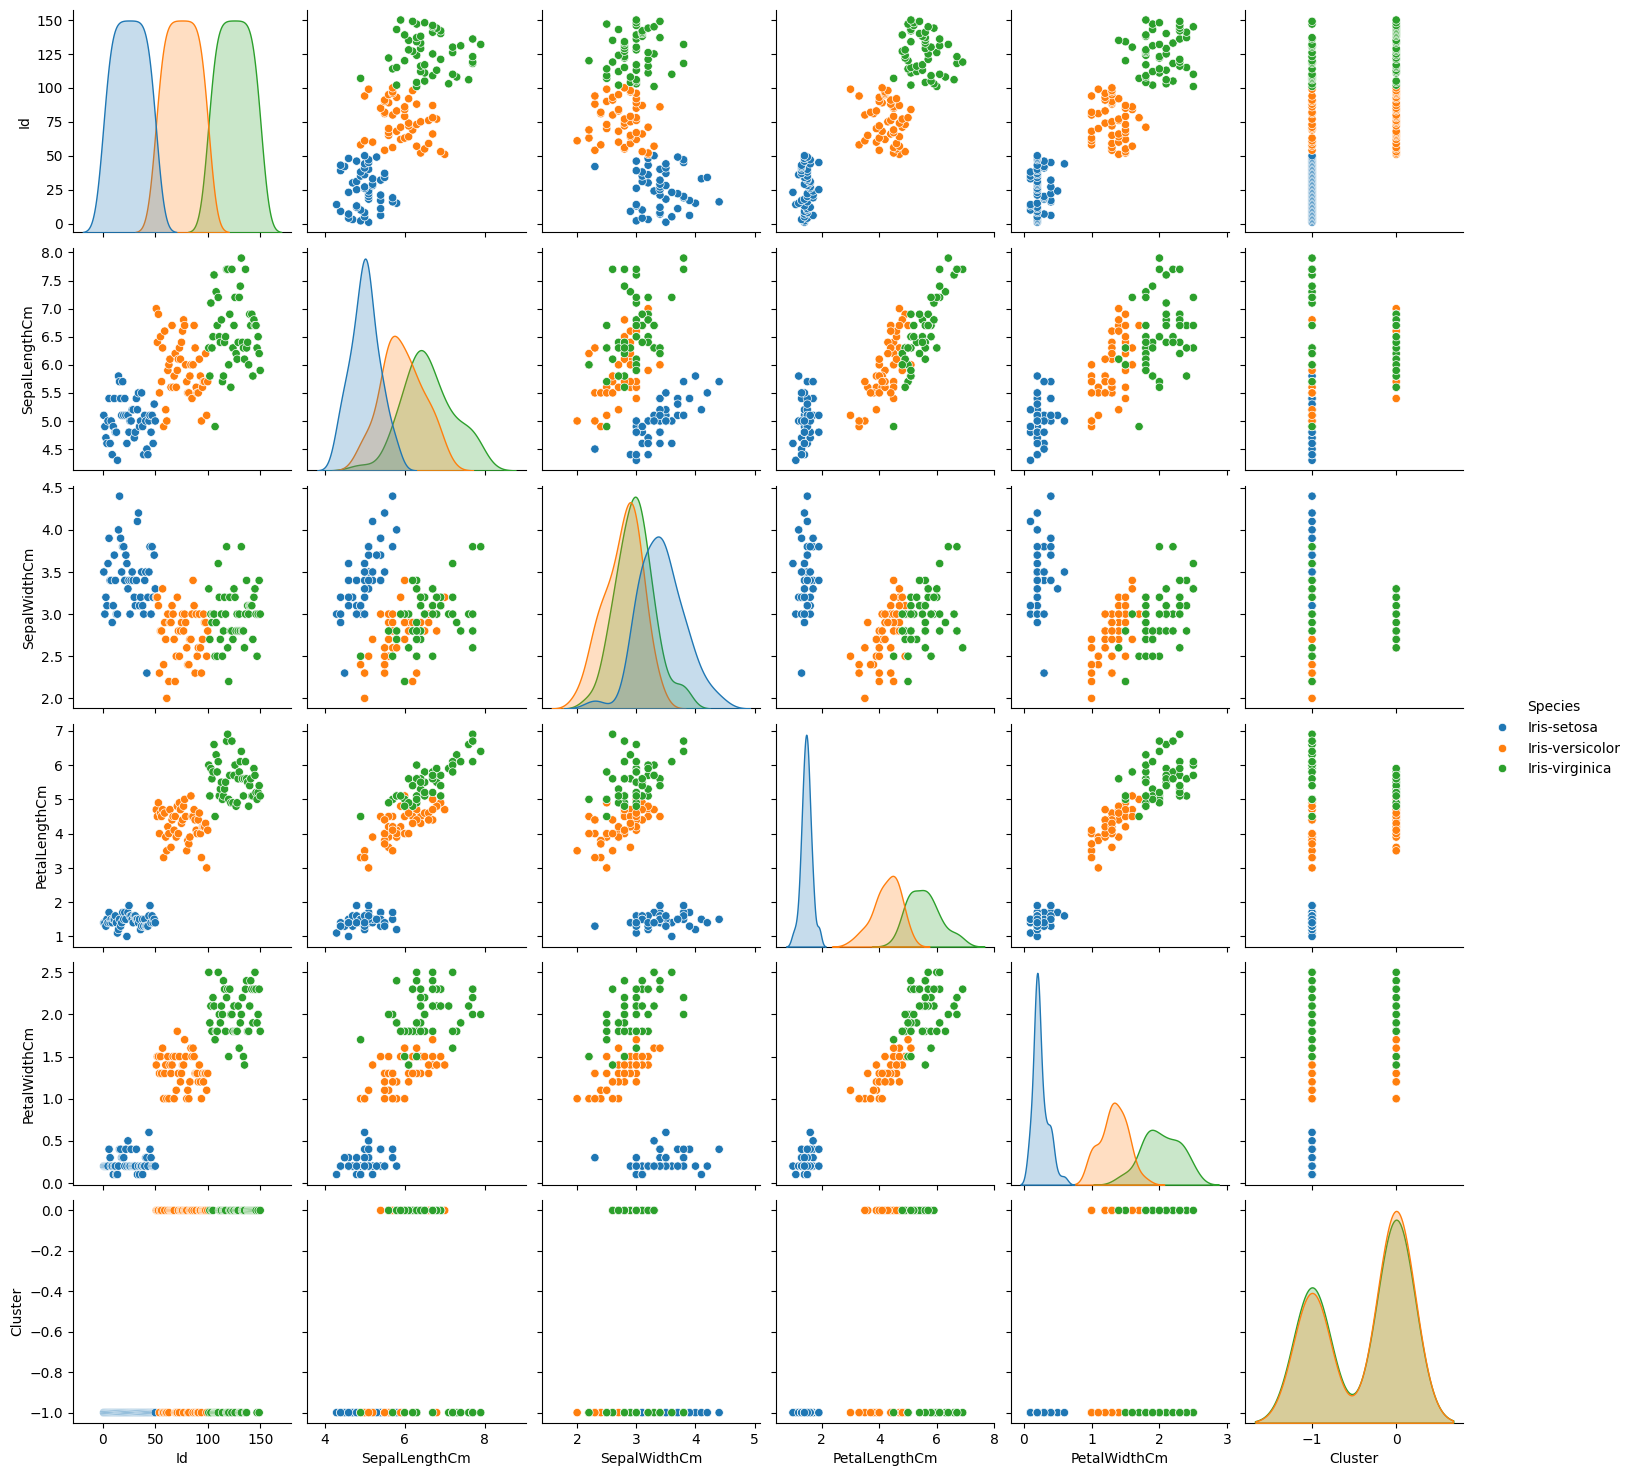

In [19]:
sns.pairplot(df, hue="Species")

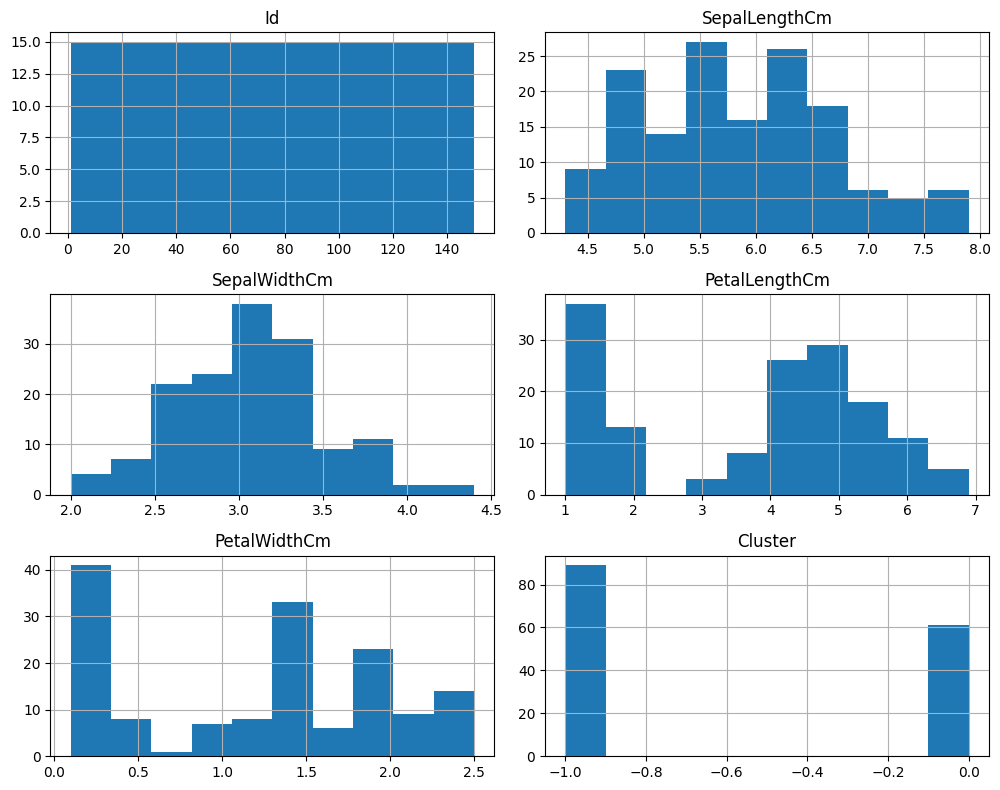

In [20]:
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

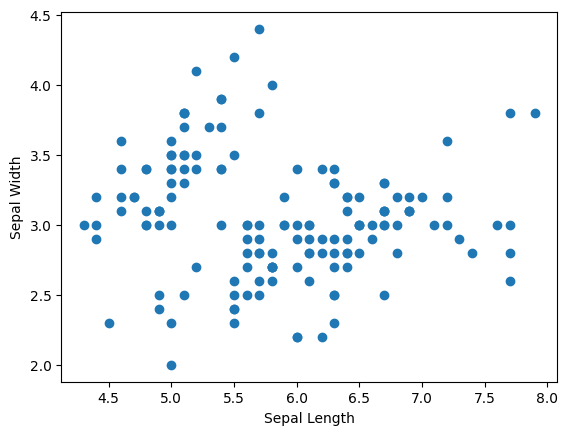

In [21]:
plt.scatter(df["SepalLengthCm"], df["SepalWidthCm"])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.show()

In [3]:
X = df[["SepalLengthCm", "SepalWidthCm"]].values

X_scaled = StandardScaler().fit_transform(X)

In [132]:
model = DBSCAN(eps=0.2675, min_samples=5)

In [133]:
dbscan_labels = model.fit_predict(X_scaled)

In [134]:
df["Cluster"] = dbscan_labels

In [135]:
print(df[["SepalLengthCm", "SepalWidthCm", "Cluster"]].head(20))

    SepalLengthCm  SepalWidthCm  Cluster
0             5.1           3.5        0
1             4.9           3.0        0
2             4.7           3.2        0
3             4.6           3.1        0
4             5.0           3.6        0
5             5.4           3.9       -1
6             4.6           3.4        0
7             5.0           3.4        0
8             4.4           2.9       -1
9             4.9           3.1        0
10            5.4           3.7       -1
11            4.8           3.4        0
12            4.8           3.0        0
13            4.3           3.0       -1
14            5.8           4.0       -1
15            5.7           4.4       -1
16            5.4           3.9       -1
17            5.1           3.5        0
18            5.7           3.8       -1
19            5.1           3.8        0


In [136]:
clusters = set(dbscan_labels)

print("Number of clusters:", len(clusters - {-1}))
print("Number of noise points:", np.sum(dbscan_labels == -1))

Number of clusters: 2
Number of noise points: 40


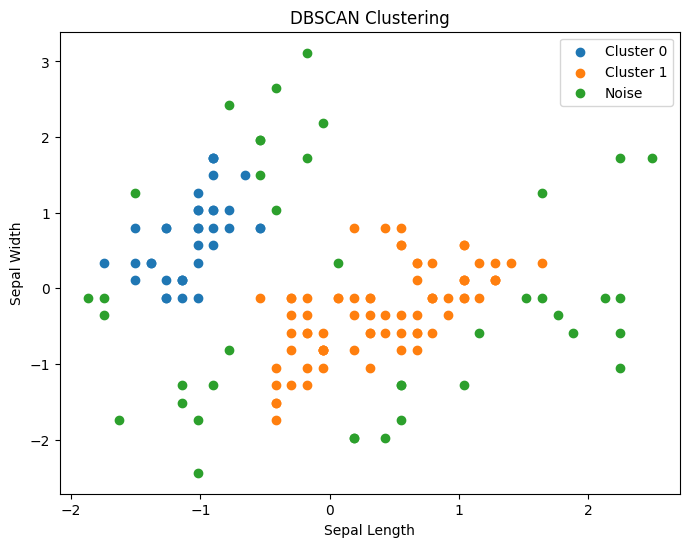

In [137]:
plt.figure(figsize=(8, 6))

for cluster in clusters:
    points = X_scaled[dbscan_labels == cluster]

    if cluster == -1:
        plt.scatter(
            points[:, 0],
            points[:, 1],
            label="Noise"
        )
    else:
        plt.scatter(
            points[:, 0],
            points[:, 1],
            label=f"Cluster {cluster}"
        )

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("DBSCAN Clustering")
plt.legend()
plt.show()

In [138]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

X = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

print("K-Means")
print("Silhouette Score:", silhouette_score(X, kmeans_labels))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X, kmeans_labels))
print("Davies-Bouldin Score:", davies_bouldin_score(X, kmeans_labels))

print("\nDBSCAN")
print("Silhouette Score:", silhouette_score(X, dbscan_labels))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X, dbscan_labels))
print("Davies-Bouldin Score:", davies_bouldin_score(X, dbscan_labels))

K-Means
Silhouette Score: 0.4787241920454202
Calinski-Harabasz Score: 156.14303764903218
Davies-Bouldin Score: 0.7868006762339904

DBSCAN
Silhouette Score: 0.31109525444284647
Calinski-Harabasz Score: 52.943446139106314
Davies-Bouldin Score: 2.9058495880470603
